# Chunking Dữ liệu v2 — RAG Soạn thảo Văn bản Hành chính

## Cấu trúc dữ liệu thực tế

```
legal_dataset (515,188 hàng)
│
├─ id          : số hiệu văn bản  → "01/2014/NQLT/CP-UBTƯMTTQVN"  (KHÔNG PHẢI chunk key)
├─ ministry    : cơ quan ban hành
├─ type        : loại văn bản
├─ name        : tên văn bản
├─ chapter_id  : số chương
├─ chapter_name: tên chương
├─ article     : tên Điều  → "Điều 1. Phạm vi điều chỉnh"  ← MỖI HÀNG = 1 ĐIỀU
└─ content     : nội dung Điều (có thể gồm nhiều khoản 1./2./a)/b)/-)
```

**Dữ liệu đã được segment theo Điều từ nguồn** — không cần tách Điều từ `id`.

## Chiến lược chunking

| Dataset | Chiến lược | Lý do |
|---------|------------|-------|
| `legal_dataset` | **Article-aware + Clause-aware** | Mỗi hàng = 1 Điều; khoản dài → split tiếp |
| `forms_dataset` | **1 template = 1 chunk** | Giữ nguyên cấu trúc placeholder |
| `forms_examples_dataset` | **1 ví dụ = 1 chunk** | Cần toàn bộ để few-shot retrieval |

## Thống kê word count (từ checkData — 10K sample)
```
median = 124 từ   → 50% điều ngắn, giữ nguyên 1 chunk
P75    = 286 từ
≤ 400 từ ≈ 82%   → đa số không cần split
≤ 1000 từ ≈ 95.7%
max    = 30,555 từ → điều có rất nhiều khoản, cần split kỹ
```

## Bug đã sửa so với v1
1. **CLAUSE_PATTERN cũ** chỉ nhận `1. `, `2. ` — bỏ sót `a)`, `b)`, `- bullet` (phổ biến trong luật VN)
2. **Thêm article header** vào đầu mỗi chunk con để giữ ngữ cảnh khi retrieval

---
## 0. Setup & Cấu hình

In [2]:
import pandas as pd
import numpy as np
import re
import json
import hashlib
from pathlib import Path
from typing import List, Dict, Tuple

# ── Đường dẫn ─────────────────────────────────────────────────────────────────
DATASET_DIR = Path("dataset/processed")
CHUNK_DIR   = Path("dataset/chunks")
CHUNK_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATHS = {
    "legal"   : DATASET_DIR / "legal_dataset_processed.parquet",
    "forms"   : DATASET_DIR / "forms_dataset_processed.parquet",
    "examples": DATASET_DIR / "forms_examples_dataset_processed.parquet",
}

OUTPUT_PATHS = {
    "legal_parquet"   : CHUNK_DIR / "legal_chunks.parquet",
    "legal_jsonl"     : CHUNK_DIR / "legal_chunks.jsonl",
    "forms_parquet"   : CHUNK_DIR / "forms_chunks.parquet",
    "forms_jsonl"     : CHUNK_DIR / "forms_chunks.jsonl",
    "examples_parquet": CHUNK_DIR / "examples_chunks.parquet",
    "examples_jsonl"  : CHUNK_DIR / "examples_chunks.jsonl",
}

print("✅ Import thành công.")
for name, path in INPUT_PATHS.items():
    status = "✅" if path.exists() else "❌ KHÔNG TÌM THẤY"
    print(f"  [{status}] {name}: {path}")

✅ Import thành công.
  [✅] legal: dataset\processed\legal_dataset_processed.parquet
  [✅] forms: dataset\processed\forms_dataset_processed.parquet
  [✅] examples: dataset\processed\forms_examples_dataset_processed.parquet


In [3]:
# ── Tham số chunking ─────────────────────────────────────────────────────────
# Dựa trên số liệu thực tế: median=124 từ, P75=286 từ
# multilingual-e5-large: max 512 tokens ≈ 400-450 từ tiếng Việt

LEGAL_MAX_WORDS     = 400   # Ngưỡng split: điều/khoản dài hơn → split tiếp
LEGAL_MIN_WORDS     = 30    # Ngưỡng merge: chunk ngắn hơn → gộp với chunk sau
LEGAL_OVERLAP_WORDS = 50    # Overlap khi dùng fixed-word fallback

print(f"⚙️  Tham số: MAX={LEGAL_MAX_WORDS}từ | MIN={LEGAL_MIN_WORDS}từ | OVERLAP={LEGAL_OVERLAP_WORDS}từ")
print(f"   → Với số liệu thực, ~82% điều sẽ là 1 chunk (không cần split)")

⚙️  Tham số: MAX=400từ | MIN=30từ | OVERLAP=50từ
   → Với số liệu thực, ~82% điều sẽ là 1 chunk (không cần split)


In [4]:
# ── Utility functions ─────────────────────────────────────────────────────────

def count_words(text: str) -> int:
    if not isinstance(text, str):
        return 0
    return len(text.split())

def make_chunk_id(doc_id: str, chunk_index: int) -> str:
    return f"{doc_id}__chunk{chunk_index:03d}"

def save_jsonl(records: List[Dict], path: Path):
    with open(path, "w", encoding="utf-8") as f:
        for rec in records:
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
    print(f"  ✅ JSONL: {path}  ({len(records):,} chunks)")

def log_chunk_stats(name: str, chunks_df: pd.DataFrame):
    wc = chunks_df["word_count"]
    print(f"\n📊 [{name}] Thống kê kích thước chunk:")
    print(f"   Tổng       : {len(chunks_df):,} chunks")
    print(f"   Min/Max    : {wc.min()} / {wc.max()} từ")
    print(f"   Mean/Median: {wc.mean():.1f} / {wc.median():.1f} từ")
    print(f"   P25/P75    : {wc.quantile(0.25):.0f} / {wc.quantile(0.75):.0f} từ")
    if (wc < 20).sum() > 0:
        print(f"   ⚠️  Chunks < 20 từ: {(wc < 20).sum():,}")
    if (wc > 600).sum() > 0:
        print(f"   ⚠️  Chunks > 600 từ: {(wc > 600).sum():,}")

print("✅ Utility functions sẵn sàng.")

✅ Utility functions sẵn sàng.


---
## 1. Legal Dataset — Article-aware + Clause-aware Chunking

### Luồng xử lý (mỗi hàng = 1 Điều)

```
Hàng (article + content)
    │
    ├─ word_count(content) ≤ MAX → giữ nguyên 1 chunk
    │                              split_type = 'article'
    │
    └─ word_count(content) > MAX → split theo khoản
            │
            ├─ Phát hiện khoản: "1. " | "a) " | "- " (v2: đầy đủ hơn v1)
            │
            ├─ khoản ≤ MAX  → 1 chunk/khoản  (split_type='clause')
            └─ khoản > MAX  → fixed-word với overlap  (split_type='fixed_word')
                                        │
            merge chunk < MIN với chunk kế tiếp
            prepend article header vào mỗi chunk con (giữ ngữ cảnh)
```

### Tại sao prepend article header?
Khi split `content` thành nhiều chunk, chunk con mất ngữ cảnh —  
LLM không biết đoạn `"1. Bộ trưởng có quyền..."` thuộc Điều nào.  
→ Thêm `"[Điều 5. Quyền và trách nhiệm]\n"` vào đầu mỗi chunk con.

In [5]:
# ── CLAUSE_PATTERN v2: nhận diện đầy đủ các dạng khoản trong luật VN ─────────
#
# Luật VN dùng 3 dạng khoản chính:
#   Khoản số:  "1. "  "2. "  "12. "
#   Khoản chữ: "a) "  "b) "  "đ) "  (gồm cả chữ đặc biệt tiếng Việt)
#   Bullet:    "- "  (đầu dòng)
#
# v1 chỉ xử lý khoản số → bỏ sót a), b), - (phổ biến trong quy định, nghị định)

CLAUSE_PATTERN = re.compile(
    r'(?:^|\n)'                    # đầu chuỗi hoặc sau newline
    r'('                            # bắt đầu capture group (label khoản)
    r'\d{1,2}\. '                  # "1. " hoặc "12. "
    r'|[a-zđ]\) '                  # "a) " "b) " "đ) " — ASCII + đ
    r'|[àáảãạăắặằẳẵâấậầẩẫ]\) '   # "ă) " "â) " — khoản hiếm nhưng có
    r'|- (?=\S)'                   # "- " bullet (phải có ký tự sau)
    r')',
    re.MULTILINE | re.UNICODE
)

# ── Test pattern trên các case thực tế ───────────────────────────────────────
test_cases = [
    ("Khoản số",
     "1. Quyền được cung cấp thông tin.\n2. Quyền được bảo vệ.\n3. Nghĩa vụ nộp thuế."),
    ("Khoản chữ a)",
     "a) Báo cáo tình hình thực hiện;\nb) Đề xuất giải pháp;\nc) Kiến nghị cấp trên."),
    ("Bullet -",
     "- Các bộ, ngành liên quan;\n- Ủy ban nhân dân tỉnh;\n- Các tổ chức, cá nhân."),
    ("Hỗn hợp số + chữ",
     "1. Bộ trưởng có quyền:\na) Quyết định chính sách;\nb) Ban hành thông tư.\n2. Thứ trưởng phụ trách."),
    ("Không có khoản",
     "Nghị quyết này hướng dẫn phối hợp thực hiện các quy định về hòa giải ở cơ sở theo quy định của pháp luật."),
]

print("=== Kiểm tra CLAUSE_PATTERN v2 ===")
for label, text in test_cases:
    parts = CLAUSE_PATTERN.split(text)
    n_clause = max(1, (len(parts) - 1) // 2 + (1 if parts[0].strip() else 0))
    found = "✅" if len(parts) > 1 or n_clause == 1 else "❌"
    print(f"  {found} [{label}]: {n_clause} khoản")

=== Kiểm tra CLAUSE_PATTERN v2 ===
  ✅ [Khoản số]: 3 khoản
  ✅ [Khoản chữ a)]: 3 khoản
  ✅ [Bullet -]: 3 khoản
  ✅ [Hỗn hợp số + chữ]: 4 khoản
  ✅ [Không có khoản]: 1 khoản


In [6]:
# ── Hàm split_into_clauses ────────────────────────────────────────────────────

def split_into_clauses(text: str) -> List[Tuple[str, str]]:
    """
    Tách nội dung 1 Điều thành các khoản.
    
    Returns:
        List of (clause_text, clause_label)
        clause_label = "1"|"a"|"bullet"|"preamble" (để debug)
    """
    parts = CLAUSE_PATTERN.split(text)
    
    if len(parts) <= 1:
        # Không tìm thấy khoản nào → trả về nguyên cả điều
        return [(text.strip(), "no_clause")]
    
    result = []
    
    # parts = [pre_text, label1, content1, label2, content2, ...]
    pre = parts[0].strip()
    if pre:
        result.append((pre, "preamble"))  # đoạn mở đầu trước khoản đầu tiên
    
    i = 1
    while i < len(parts) - 1:
        label   = parts[i].strip()       # "1.", "a)", "-"
        content = parts[i + 1]           # nội dung khoản
        clause_text = (label + " " + content).strip()
        if clause_text:
            # Xác định loại khoản để gắn nhãn
            if re.match(r'\d', label):
                ctype = "numbered"
            elif label.startswith("-"):
                ctype = "bullet"
            else:
                ctype = "lettered"
            result.append((clause_text, ctype))
        i += 2
    
    return result if result else [(text.strip(), "no_clause")]


def fixed_word_split(text: str, max_words: int, overlap_words: int) -> List[str]:
    """Fallback: split cứng theo số từ với overlap."""
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = min(start + max_words, len(words))
        chunks.append(" ".join(words[start:end]))
        if end == len(words):
            break
        start = end - overlap_words
    return chunks


print("✅ split_into_clauses và fixed_word_split đã định nghĩa.")

✅ split_into_clauses và fixed_word_split đã định nghĩa.


In [7]:
# ── Hàm chunking chính ────────────────────────────────────────────────────────

def chunk_legal_row(
    row: pd.Series,
    max_words: int   = LEGAL_MAX_WORDS,
    min_words: int   = LEGAL_MIN_WORDS,
    overlap_words: int = LEGAL_OVERLAP_WORDS
) -> List[Dict]:
    """
    Chunking 1 hàng legal (= 1 Điều) → list chunk dicts.

    Input columns: doc_id, id, ministry, type_normalized, name,
                   chapter_id, chapter_name, article, content
    """
    content = str(row.get("content", "") or "").strip()
    article = str(row.get("article", "") or "").strip()   # "Điều 5. Quyền và trách nhiệm"
    doc_id  = str(row.get("doc_id", ""))

    # Metadata dùng chung cho mọi chunk từ hàng này
    meta = {
        "doc_id"          : doc_id,
        "source_doc_no"   : str(row.get("id", "") or ""),      # số hiệu văn bản gốc
        "ministry"        : str(row.get("ministry", "") or ""),
        "type_normalized" : str(row.get("type_normalized", "") or ""),
        "doc_name"        : str(row.get("name", "") or ""),
        "chapter_id"      : str(row.get("chapter_id", "") or ""),
        "chapter_name"    : str(row.get("chapter_name", "") or ""),
        "article"         : article,
    }

    # ── CASE 1: Điều ngắn → giữ nguyên 1 chunk ───────────────────────────────
    if count_words(content) <= max_words:
        text = f"{article}\n{content}" if article else content
        return [{
            "chunk_id"    : make_chunk_id(doc_id, 0),
            **meta,
            "chunk_index" : 0,
            "total_chunks": 1,
            "split_type"  : "article",
            "text"        : text,
            "word_count"  : count_words(text),
        }]

    # ── CASE 2: Điều dài → split theo khoản ──────────────────────────────────
    clauses = split_into_clauses(content)  # [(text, type), ...]

    # Mỗi khoản nếu vẫn quá dài → fixed_word split
    raw_segments = []   # list of (text, split_type_str)

    if len(clauses) == 1 and clauses[0][1] == "no_clause":
        # Không tìm được khoản nào → fixed_word fallback cho toàn bộ content
        for seg in fixed_word_split(content, max_words, overlap_words):
            raw_segments.append((seg, "fixed_word"))
    else:
        for clause_text, clause_type in clauses:
            if count_words(clause_text) <= max_words:
                stype = "clause" if clause_type != "preamble" else "preamble"
                raw_segments.append((clause_text, stype))
            else:
                # Khoản vẫn quá dài → fixed_word
                for seg in fixed_word_split(clause_text, max_words, overlap_words):
                    raw_segments.append((seg, "fixed_word"))

    # ── BƯỚC MERGE: gộp chunk quá ngắn với chunk tiếp theo ───────────────────
    merged = []
    buf_text = ""
    buf_type = ""

    for seg_text, seg_type in raw_segments:
        seg_text = seg_text.strip()
        if not seg_text:
            continue
        if buf_text and count_words(buf_text) < min_words:
            buf_text = buf_text + "\n" + seg_text
            # giữ type của đoạn đầu
        else:
            if buf_text:
                merged.append((buf_text, buf_type))
            buf_text = seg_text
            buf_type = seg_type

    if buf_text.strip():
        merged.append((buf_text.strip(), buf_type))

    # ── TẠO CHUNK DICTS ───────────────────────────────────────────────────────
    # Prepend article header vào mỗi chunk con để giữ ngữ cảnh khi retrieval
    # VD: "[Điều 5. Quyền và trách nhiệm]\n1. Bộ trưởng có quyền..."
    article_header = f"[{article}]" if article else ""
    total = len(merged)
    chunks = []

    for idx, (seg_text, seg_type) in enumerate(merged):
        if total > 1 and article_header:
            # Chỉ thêm header cho chunk con (khi đã split)
            text = f"{article_header}\n{seg_text}"
        else:
            text = seg_text

        chunk = {
            "chunk_id"    : make_chunk_id(doc_id, idx),
            **meta,
            "chunk_index" : idx,
            "total_chunks": total,
            "split_type"  : seg_type,
            "text"        : text,
            "word_count"  : count_words(text),
        }
        chunks.append(chunk)

    return chunks


print("✅ chunk_legal_row đã định nghĩa.")

✅ chunk_legal_row đã định nghĩa.


In [8]:
# ── Test với dữ liệu mô phỏng đúng schema thực ───────────────────────────────

test_cases = [
    # Case A: Điều ngắn → 1 chunk
    pd.Series({
        "doc_id": "01/2014/NQLT__Điều_1__abc1",
        "id": "01/2014/NQLT/CP-UBTƯMTTQVN",
        "ministry": "CHÍNH PHỦ - ỦY BAN TRUNG ƯƠNG MẶT TRẬN TỔ QUỐC VIỆT NAM",
        "type_normalized": "NGHỊ QUYẾT LIÊN TỊCH",
        "name": "HƯỚNG DẪN PHỐI HỢP THỰC HIỆN MỘT SỐ QUY ĐỊNH CỦA PHÁP LUẬT VỀ HÒA GIẢI Ở CƠ SỞ",
        "chapter_id": "Chương I",
        "chapter_name": "NHỮNG QUY ĐỊNH CHUNG",
        "article": "Điều 1. Phạm vi điều chỉnh",
        "content": "Nghị quyết liên tịch này hướng dẫn phối hợp thực hiện một số quy định của pháp luật về hòa giải ở cơ sở theo quy định.",
    }),
    # Case B: Điều có khoản a), b), c) → split theo chữ
    pd.Series({
        "doc_id": "30/2020/NĐ-CP__Điều_5__abc2",
        "id": "30/2020/NĐ-CP",
        "ministry": "Bộ Nội vụ",
        "type_normalized": "NGHỊ ĐỊNH",
        "name": "Nghị định 30/2020 về công tác văn thư",
        "chapter_id": "II",
        "chapter_name": "Soạn thảo và ban hành văn bản",
        "article": "Điều 5. Quyền và trách nhiệm của cán bộ, công chức trong công tác văn thư",
        "content": " ".join([
            "Cán bộ, công chức trong công tác văn thư có các quyền và trách nhiệm sau:",
            "a) Được cung cấp đầy đủ thông tin, tài liệu cần thiết phục vụ công việc được giao;",
            "được tham dự các lớp bồi dưỡng, tập huấn về nghiệp vụ văn thư lưu trữ theo quy định.",
            "b) Bảo đảm giữ gìn bí mật nội dung văn bản theo quy định của pháp luật;",
            "không làm thất lạc, hư hỏng văn bản, tài liệu được giao quản lý theo quy định hiện hành.",
            "c) Thực hiện đúng, đầy đủ quy trình quản lý văn bản đến, văn bản đi;",
            "lập hồ sơ và nộp lưu hồ sơ, tài liệu vào lưu trữ cơ quan theo quy định.",
        ] * 20)   # nhân 20x để vượt ngưỡng 400 từ
    }),
]

for row in test_cases:
    chunks = chunk_legal_row(row, max_words=400)
    print(f"\n📄 article: {row['article'][:60]}")
    print(f"   content : {count_words(row['content'])} từ")
    print(f"   → {len(chunks)} chunk(s)")
    for c in chunks:
        print(f"     [{c['chunk_index']}] split={c['split_type']:10s} | {c['word_count']} từ | {c['text'][:80]}...")


📄 article: Điều 1. Phạm vi điều chỉnh
   content : 27 từ
   → 1 chunk(s)
     [0] split=article    | 33 từ | Điều 1. Phạm vi điều chỉnh
Nghị quyết liên tịch này hướng dẫn phối hợp thực hiện...

📄 article: Điều 5. Quyền và trách nhiệm của cán bộ, công chức trong côn
   content : 2460 từ
   → 7 chunk(s)
     [0] split=fixed_word | 416 từ | [Điều 5. Quyền và trách nhiệm của cán bộ, công chức trong công tác văn thư]
Cán ...
     [1] split=fixed_word | 416 từ | [Điều 5. Quyền và trách nhiệm của cán bộ, công chức trong công tác văn thư]
đi; ...
     [2] split=fixed_word | 416 từ | [Điều 5. Quyền và trách nhiệm của cán bộ, công chức trong công tác văn thư]
quy ...
     [3] split=fixed_word | 416 từ | [Điều 5. Quyền và trách nhiệm của cán bộ, công chức trong công tác văn thư]
định...
     [4] split=fixed_word | 416 từ | [Điều 5. Quyền và trách nhiệm của cán bộ, công chức trong công tác văn thư]
thư ...
     [5] split=fixed_word | 416 từ | [Điều 5. Quyền và trách nhiệm của cán bộ, công chức tr

In [9]:
# ── Chạy chunking toàn bộ legal_dataset ──────────────────────────────────────
print("Đang đọc legal_dataset_processed...")
legal_df = pd.read_parquet(INPUT_PATHS["legal"], engine="pyarrow")
print(f"✅ {len(legal_df):,} hàng | cột: {list(legal_df.columns)}")

print("\nĐang chunking...")
all_chunks = []

for i, (_, row) in enumerate(legal_df.iterrows()):
    all_chunks.extend(chunk_legal_row(row))
    if (i + 1) % 50_000 == 0:
        print(f"  [{i+1:,}/{len(legal_df):,}] Chunks: {len(all_chunks):,}")

print(f"\n✅ Chunking hoàn tất!")
print(f"   Hàng gốc     : {len(legal_df):,}")
print(f"   Tổng chunks  : {len(all_chunks):,}")
print(f"   Tỉ lệ mở rộng: {len(all_chunks)/len(legal_df):.2f}x")

Đang đọc legal_dataset_processed...
✅ 392,079 hàng | cột: ['doc_id', 'id', 'ministry', 'type_normalized', 'name', 'chapter_id', 'chapter_name', 'article', 'content']

Đang chunking...
  [50,000/392,079] Chunks: 64,582
  [100,000/392,079] Chunks: 127,904
  [150,000/392,079] Chunks: 207,358
  [200,000/392,079] Chunks: 291,726
  [250,000/392,079] Chunks: 377,327
  [300,000/392,079] Chunks: 457,450
  [350,000/392,079] Chunks: 532,376

✅ Chunking hoàn tất!
   Hàng gốc     : 392,079
   Tổng chunks  : 593,430
   Tỉ lệ mở rộng: 1.51x


In [10]:
# ── Thống kê & kiểm tra ───────────────────────────────────────────────────────
legal_chunks_df = pd.DataFrame(all_chunks)

# chunk_id unique
dup = legal_chunks_df["chunk_id"].duplicated().sum()
print("✅ Tất cả chunk_id duy nhất" if dup == 0 else f"⚠️ {dup} chunk_id trùng")

# Phân bố split_type
print("\nPhân bố split_type:")
st = legal_chunks_df["split_type"].value_counts()
for k, v in st.items():
    print(f"  {k:12s}: {v:,}  ({v/len(legal_chunks_df)*100:.1f}%)")

# Phân phối word count
log_chunk_stats("legal_dataset", legal_chunks_df)

# Xem thử
print("\n--- 3 chunk mẫu ---")
display(legal_chunks_df[["chunk_id", "article", "split_type", "word_count", "text"]].head(3))

✅ Tất cả chunk_id duy nhất

Phân bố split_type:
  article     : 307,889  (51.9%)
  fixed_word  : 285,541  (48.1%)

📊 [legal_dataset] Thống kê kích thước chunk:
   Tổng       : 593,430 chunks
   Min/Max    : 2 / 705 từ
   Mean/Median: 258.4 / 252.0 từ
   P25/P75    : 124 / 407 từ
   ⚠️  Chunks < 20 từ: 1,637
   ⚠️  Chunks > 600 từ: 61

--- 3 chunk mẫu ---


,chunk_id,article,split_type,word_count,text
0,01/2014/NQLT/CP-UBTƯMTTQVN__Điều_1._Phạm_vi_đi...,Điều 1. Phạm vi điều chỉnh,article,54,Điều 1. Phạm vi điều chỉnh\nNghị quyết liên tị...
1,01/2014/NQLT/CP-UBTƯMTTQVN__Điều_2._Nguyên_tắc...,Điều 2. Nguyên tắc phối hợp,article,101,Điều 2. Nguyên tắc phối hợp\n1. Việc phối hợp ...
2,01/2014/NQLT/CP-UBTƯMTTQVN__Điều_3._Hướng_dẫn_...,Điều 3. Hướng dẫn và tổ chức thực hiện các quy...,article,141,Điều 3. Hướng dẫn và tổ chức thực hiện các quy...


In [11]:
# ── Lưu legal chunks ──────────────────────────────────────────────────────────
legal_chunks_df.to_parquet(OUTPUT_PATHS["legal_parquet"], engine="pyarrow", index=False)
mb = OUTPUT_PATHS["legal_parquet"].stat().st_size / 1024 / 1024
print(f"✅ Parquet: {OUTPUT_PATHS['legal_parquet']}  ({mb:.1f} MB)")

save_jsonl(all_chunks, OUTPUT_PATHS["legal_jsonl"])

✅ Parquet: dataset\chunks\legal_chunks.parquet  (326.6 MB)
  ✅ JSONL: dataset\chunks\legal_chunks.jsonl  (593,430 chunks)


---
## 2. Forms Dataset — 1 Template = 1 Chunk

In [12]:
forms_df = pd.read_parquet(INPUT_PATHS["forms"], engine="pyarrow")
print(f"✅ {len(forms_df)} forms | cột: {list(forms_df.columns)}")

forms_chunks = []
for _, row in forms_df.iterrows():
    doc_id = str(row.get("doc_id", row.get("form_id", "")))
    tmpl_col = "template_markdown" if "template_markdown" in row.index else "template"
    text = str(row.get(tmpl_col, "") or "")

    req = row.get("required_fields", [])
    if isinstance(req, np.ndarray): req = req.tolist()
    elif isinstance(req, str):
        try: req = json.loads(req)
        except: req = []

    forms_chunks.append({
        "chunk_id"       : make_chunk_id(doc_id, 0),
        "doc_id"         : doc_id,
        "form_id"        : str(row.get("form_id", "")),
        "form_type"      : str(row.get("form_type", "") or ""),
        "purpose"        : str(row.get("purpose", "") or ""),
        "required_fields": req,
        "chunk_index"    : 0,
        "total_chunks"   : 1,
        "split_type"     : "full_template",
        "text"           : text,
        "word_count"     : count_words(text),
    })

forms_chunks_df = pd.DataFrame(forms_chunks)
log_chunk_stats("forms_dataset", forms_chunks_df)

forms_chunks_df.to_parquet(OUTPUT_PATHS["forms_parquet"], engine="pyarrow", index=False)
print(f"\n✅ Parquet: {OUTPUT_PATHS['forms_parquet']}")
save_jsonl(forms_chunks, OUTPUT_PATHS["forms_jsonl"])

✅ 10 forms | cột: ['doc_id', 'form_id', 'form_type', 'purpose', 'required_fields', 'template_markdown']

📊 [forms_dataset] Thống kê kích thước chunk:
   Tổng       : 10 chunks
   Min/Max    : 50 / 100 từ
   Mean/Median: 76.2 / 72.5 từ
   P25/P75    : 67 / 93 từ

✅ Parquet: dataset\chunks\forms_chunks.parquet
  ✅ JSONL: dataset\chunks\forms_chunks.jsonl  (10 chunks)


---
## 3. Forms Examples Dataset — 1 Ví dụ = 1 Chunk

In [13]:
examples_df = pd.read_parquet(INPUT_PATHS["examples"], engine="pyarrow")
print(f"✅ {len(examples_df)} ví dụ | cột: {list(examples_df.columns)}")

examples_chunks = []
for _, row in examples_df.iterrows():
    doc_id = str(row.get("doc_id", row.get("example_id", "")))
    text   = str(row.get("filled_content", "") or "")

    examples_chunks.append({
        "chunk_id"    : make_chunk_id(doc_id, 0),
        "doc_id"      : doc_id,
        "example_id"  : str(row.get("example_id", "") or ""),
        "form_id"     : str(row.get("form_id", "") or ""),
        "form_type"   : str(row.get("form_type", "") or ""),
        "scenario"    : str(row.get("scenario", "") or ""),
        "fields_json" : str(row.get("fields_json", "{}") or "{}"),
        "chunk_index" : 0,
        "total_chunks": 1,
        "split_type"  : "full_example",
        "text"        : text,
        "word_count"  : count_words(text),
    })

examples_chunks_df = pd.DataFrame(examples_chunks)
log_chunk_stats("forms_examples_dataset", examples_chunks_df)

examples_chunks_df.to_parquet(OUTPUT_PATHS["examples_parquet"], engine="pyarrow", index=False)
print(f"\n✅ Parquet: {OUTPUT_PATHS['examples_parquet']}")
save_jsonl(examples_chunks, OUTPUT_PATHS["examples_jsonl"])

✅ 150 ví dụ | cột: ['doc_id', 'form_id', 'form_type', 'example_id', 'scenario', 'fields_json', 'filled_content']

📊 [forms_examples_dataset] Thống kê kích thước chunk:
   Tổng       : 150 chunks
   Min/Max    : 133 / 473 từ
   Mean/Median: 278.5 / 280.0 từ
   P25/P75    : 218 / 330 từ

✅ Parquet: dataset\chunks\examples_chunks.parquet
  ✅ JSONL: dataset\chunks\examples_chunks.jsonl  (150 chunks)


---
## 4. Tổng kết & Kiểm tra Output

In [14]:
print("=" * 70)
print("         BÁO CÁO CHUNKING v2")
print("=" * 70)

total_all = 0
datasets_info = [
    ("legal_dataset",          OUTPUT_PATHS["legal_parquet"],    OUTPUT_PATHS["legal_jsonl"]),
    ("forms_dataset",          OUTPUT_PATHS["forms_parquet"],    OUTPUT_PATHS["forms_jsonl"]),
    ("forms_examples_dataset", OUTPUT_PATHS["examples_parquet"], OUTPUT_PATHS["examples_jsonl"]),
]

for name, parquet_path, jsonl_path in datasets_info:
    if not parquet_path.exists():
        print(f"\n[{name}] ❌ Chưa tạo được"); continue

    df = pd.read_parquet(parquet_path, engine="pyarrow")
    wc = df["word_count"]
    total_all += len(df)
    p_mb = parquet_path.stat().st_size / 1024 / 1024
    j_mb = jsonl_path.stat().st_size / 1024 / 1024 if jsonl_path.exists() else 0

    print(f"\n[{name}]")
    print(f"  Chunks   : {len(df):,}")
    print(f"  WordCount: mean={wc.mean():.0f} | median={wc.median():.0f} | min={wc.min()} | max={wc.max()}")
    if "split_type" in df.columns:
        print(f"  SplitType: {df['split_type'].value_counts().to_dict()}")
    print(f"  Files    : {parquet_path.name} ({p_mb:.1f}MB) | {jsonl_path.name} ({j_mb:.1f}MB)")

print(f"\n{'='*70}")
print(f"  TỔNG CỘNG: {total_all:,} chunks")
print(f"{'='*70}")

         BÁO CÁO CHUNKING v2

[legal_dataset]
  Chunks   : 593,430
  WordCount: mean=258 | median=252 | min=2 | max=705
  SplitType: {'article': 307889, 'fixed_word': 285541}
  Files    : legal_chunks.parquet (326.6MB) | legal_chunks.jsonl (1336.2MB)

[forms_dataset]
  Chunks   : 10
  WordCount: mean=76 | median=72 | min=50 | max=100
  SplitType: {'full_template': 10}
  Files    : forms_chunks.parquet (0.0MB) | forms_chunks.jsonl (0.0MB)

[forms_examples_dataset]
  Chunks   : 150
  WordCount: mean=278 | median=280 | min=133 | max=473
  SplitType: {'full_example': 150}
  Files    : examples_chunks.parquet (0.2MB) | examples_chunks.jsonl (0.8MB)

  TỔNG CỘNG: 593,590 chunks


In [15]:
# ── Kiểm tra toàn vẹn schema ─────────────────────────────────────────────────
checks = [
    ("legal",    OUTPUT_PATHS["legal_parquet"],    ["chunk_id","doc_id","article","split_type","text","word_count"]),
    ("forms",    OUTPUT_PATHS["forms_parquet"],    ["chunk_id","doc_id","form_type","text","word_count"]),
    ("examples", OUTPUT_PATHS["examples_parquet"], ["chunk_id","doc_id","form_type","text","word_count"]),
]
print("--- SCHEMA CHECK ---")
for name, path, req_cols in checks:
    df = pd.read_parquet(path, engine="pyarrow")
    missing_cols = [c for c in req_cols if c not in df.columns]
    dup_ids   = df["chunk_id"].duplicated().sum()
    empty_txt = (df["text"].fillna("").str.strip() == "").sum()
    ok = not missing_cols and dup_ids == 0 and empty_txt == 0
    print(f"  [{'✅' if ok else '❌'}] {name}: {len(df):,} chunks | "
          f"dup_ids={dup_ids} | empty_text={empty_txt}"
          + (f" | missing_cols={missing_cols}" if missing_cols else ""))

--- SCHEMA CHECK ---
  [✅] legal: 593,430 chunks | dup_ids=0 | empty_text=0
  [✅] forms: 10 chunks | dup_ids=0 | empty_text=0
  [✅] examples: 150 chunks | dup_ids=0 | empty_text=0


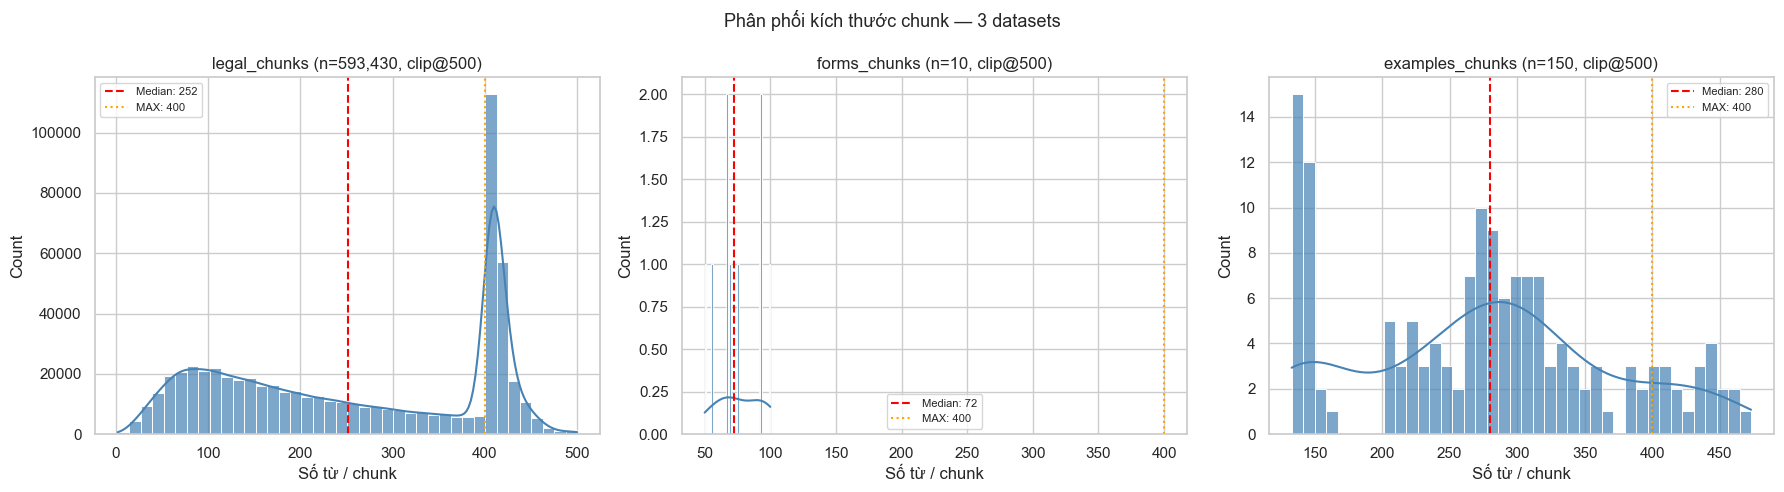

In [16]:
# ── Biểu đồ phân phối word count ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, path) in zip(axes, [
    ("legal_chunks",    OUTPUT_PATHS["legal_parquet"]),
    ("forms_chunks",    OUTPUT_PATHS["forms_parquet"]),
    ("examples_chunks", OUTPUT_PATHS["examples_parquet"]),
]):
    if not path.exists(): continue
    df = pd.read_parquet(path, engine="pyarrow")
    wc = df["word_count"].clip(upper=500)
    sns.histplot(wc, bins=40, kde=True, ax=ax, color="steelblue", alpha=0.7)
    ax.axvline(wc.median(), color="red", linestyle="--", lw=1.5, label=f"Median: {wc.median():.0f}")
    ax.axvline(LEGAL_MAX_WORDS, color="orange", linestyle=":", lw=1.5, label=f"MAX: {LEGAL_MAX_WORDS}")
    ax.set_title(f"{name} (n={len(df):,}, clip@500)")
    ax.set_xlabel("Số từ / chunk")
    ax.legend(fontsize=8)

plt.suptitle("Phân phối kích thước chunk — 3 datasets", fontsize=13)
plt.tight_layout()
plt.savefig(CHUNK_DIR / "chunk_distribution_v2.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Thay đổi so với v1 & Ghi chú

### Bug đã sửa

| Vấn đề | v1 | v2 |
|--------|----|----|  
| CLAUSE_PATTERN | Chỉ `"1. "`, `"2. "` | Thêm `"a) "`, `"b) "`, `"- "` (đầy đủ dạng khoản VN) |
| Context chunk con | Mất ngữ cảnh Điều khi split | Prepend `[Điều X.]` vào đầu chunk con |
| Nhầm `id` với chunk key | Không có — `id` chỉ là metadata | Làm rõ: `id` = số hiệu văn bản, `doc_id` = hash từ preprocessing |

### Điều chỉnh tham số

| Tham số | Mặc định | Khi nào thay đổi |
|---------|----------|------------------|
| `LEGAL_MAX_WORDS` | 400 | Đổi embedding model → điều chỉnh theo max token |
| `LEGAL_MIN_WORDS` | 30 | Giảm nếu muốn giữ chunk ngắn; tăng để hạn chế chunk li ti |
| `LEGAL_OVERLAP_WORDS` | 50 | Tăng nếu fixed_word chunk mất context ở biên |

### Bước tiếp theo
1. Nạp JSONL vào vector store (Qdrant / Chroma)
2. Embed bằng `multilingual-e5-large-instruct` hoặc `bge-m3`
3. Retrieval test với các query thực tế